In [79]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [80]:
def cargar_datos_json(ruta_carpeta):
    dataframes = []
    
    # 1. Iterar sobre todos los archivos JSON en la carpeta
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith('.json'):
            # Extraer la clase del nombre del archivo (ej. "Fall .json.xxx" -> "Fall")
            clase = archivo.split('.')[0].strip()
            
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            with open(ruta_completa, 'r') as f:
                data = json.load(f)
            
            # 2. Navegar por el JSON de Edge Impulse para sacar los valores
            if 'payload' in data and 'values' in data['payload']:
                # Convertir a matriz matemática para operarlos fácilmente
                valores = np.array(data['payload']['values'])
                
                # ax, ay, az están en las columnas 0, 1, 2
                ax = valores[:, 0]
                ay = valores[:, 1]
                az = valores[:, 2]
                
                # 3. FEATURE ENGINEERING: Resumir los 3 segundos de datos en estadísticas
                features = {
                    'mean_x': np.mean(ax),
                    'std_x': np.std(ax),
                    'mean_y': np.mean(ay),
                    'std_y': np.std(ay),
                    'mean_z': np.mean(az),
                    'std_z': np.std(az),
                    # Magnitud total (filtra un poco el problema de rotación del sensor)
                    'magnitud_mean': np.mean(np.sqrt(ax**2 + ay**2 + az**2)),
                    'clase': clase
                }
                dataframes.append(features)
                
    return pd.DataFrame(dataframes)

In [81]:
ruta_carpeta = './datos/ml-watch-movement-classification-export/training'

In [82]:
print("Cargando datos y extrayendo características...")
df_final = cargar_datos_json(ruta_carpeta)

Cargando datos y extrayendo características...


In [83]:
df_final.head()

,mean_x,std_x,mean_y,std_y,mean_z,std_z,magnitud_mean,clase
0,2.517022,0.517904,-9.623022,0.810962,2.059822,1.011176,10.226598,Walking
1,3.168356,0.046067,-9.213422,0.029744,2.656711,0.043826,10.098893,Quiet
2,2.600178,0.923051,-9.559578,1.094047,2.009200,1.161697,10.222728,Walking
3,3.273267,0.112367,-9.213644,0.092410,2.534956,0.098315,10.102041,Quiet
4,5.384741,1.980974,-5.754889,2.926720,4.731778,3.300617,10.294658,Bend


In [84]:
print(f"Total de muestras procesadas: {len(df_final)}")
print(f"Clases detectadas: {df_final['clase'].unique()}\n")

Total de muestras procesadas: 74
Clases detectadas: <StringArray>
['Walking', 'Quiet', 'Bend', 'Fall']
Length: 4, dtype: str



In [85]:
X = df_final.drop('clase', axis=1)
y = df_final['clase']

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [88]:
predicciones = modelo.predict(X_test)
print("================ RESULTADOS ================")
print(f"Precisión General: {accuracy_score(y_test, predicciones) * 100:.2f}%\n")
print(classification_report(y_test, predicciones))

================ RESULTADOS ================
Precisión General: 93.33%

              precision    recall  f1-score   support

        Bend       0.83      1.00      0.91         5
        Fall       1.00      1.00      1.00         3
       Quiet       1.00      1.00      1.00         2
     Walking       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.96      0.95      0.95        15
weighted avg       0.94      0.93      0.93        15



In [89]:
from micromlgen import port

# Convertimos tu Random Forest a un archivo de cabecera de C++
# (Asegúrate de que 'modelo' es la variable de tu RandomForestClassifier)
codigo_c = port(modelo)

# Lo guardamos en un archivo
with open('basic_structure/Modelo_Movimiento.h', 'w') as f:
    f.write(codigo_c)

print("¡Modelo exportado con éxito a C++!")

¡Modelo exportado con éxito a C++!


In [90]:
# Mensaje útil para el código de Arduino
print("Las clases en tu ESP32 deben estar en este EXACTO orden:")
print(list(modelo.classes_))

Las clases en tu ESP32 deben estar en este EXACTO orden:
['Bend', 'Fall', 'Quiet', 'Walking']


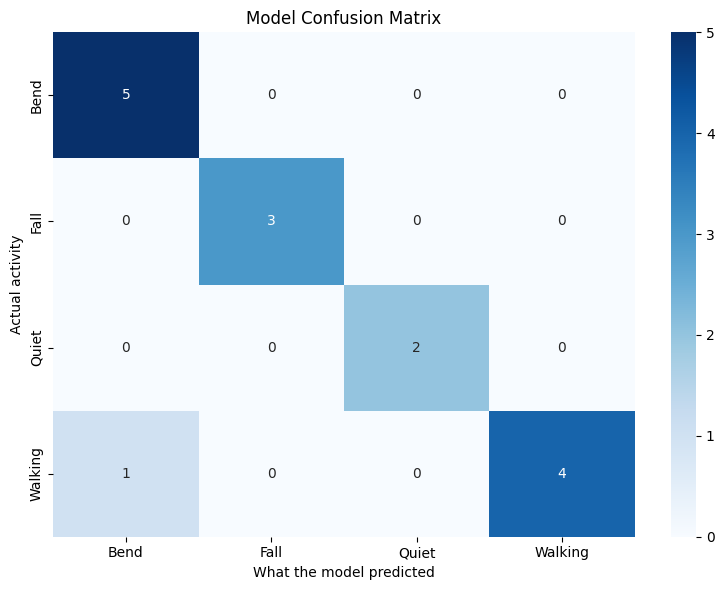

In [ ]:
# GRÁFICO 1: Matriz de Confusión
plt.figure(figsize=(8, 6))

clases_modelo = modelo.classes_
cm = confusion_matrix(y_test, predicciones, labels=clases_modelo)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=clases_modelo, yticklabels=clases_modelo
)
plt.title('Model Confusion Matrix')
plt.xlabel('What the model predicted')
plt.ylabel('Actual activity')
plt.tight_layout()

# Crear carpeta si no existe
os.makedirs('imagenes', exist_ok=True)

# Guardar primero
plt.savefig('imagenes/model_confusion_matrix.png', dpi=300, bbox_inches='tight')

# Luego mostrar
plt.show()

/tmp/ipykernel_26366/1266092794.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_ordenadas, y=nombres_ordenados, palette='viridis')


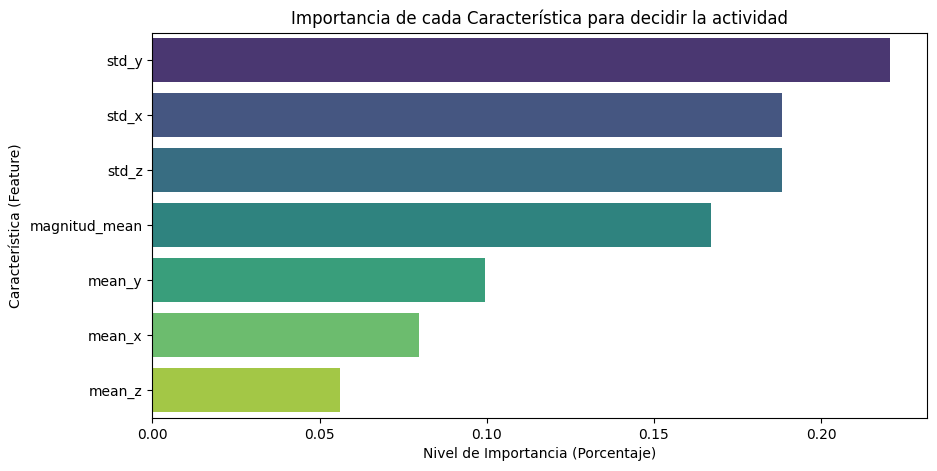

In [92]:
# GRÁFICO 2: Importancia de Características (Feature Importance)
plt.figure(figsize=(10, 5))
importancias = modelo.feature_importances_
nombres_features = X.columns

# Ordenamos de mayor a menor importancia para que se vea mejor
indices_ordenados = np.argsort(importancias)[::-1]
importancias_ordenadas = importancias[indices_ordenados]
nombres_ordenados = nombres_features[indices_ordenados]

sns.barplot(x=importancias_ordenadas, y=nombres_ordenados, palette='viridis')
plt.title('Importancia de cada Característica para decidir la actividad')
plt.xlabel('Nivel de Importancia (Porcentaje)')
plt.ylabel('Característica (Feature)')
plt.show()